# Aufgabe 2

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.filters import gaussian, laplace
from scipy.ndimage import convolve
import time

In [77]:
img_original = imread("einstein.png")

## 2.1

Da die Faltung assoziativ ist, kann man die beiden Kernel (Gauß und Laplace) zuerst zusammenfalten und erhält einen kombinierten Kern, den **Laplacian of Gaussian (LoG)**. Das Bild muss dann nur einmal mit diesem kombinierten Kern gefiltert werden und ergibt das gleiche Ergebnis wie die hintereinander durchgeführte Anwendung der zwei einzelnen Filter.

## 2.2

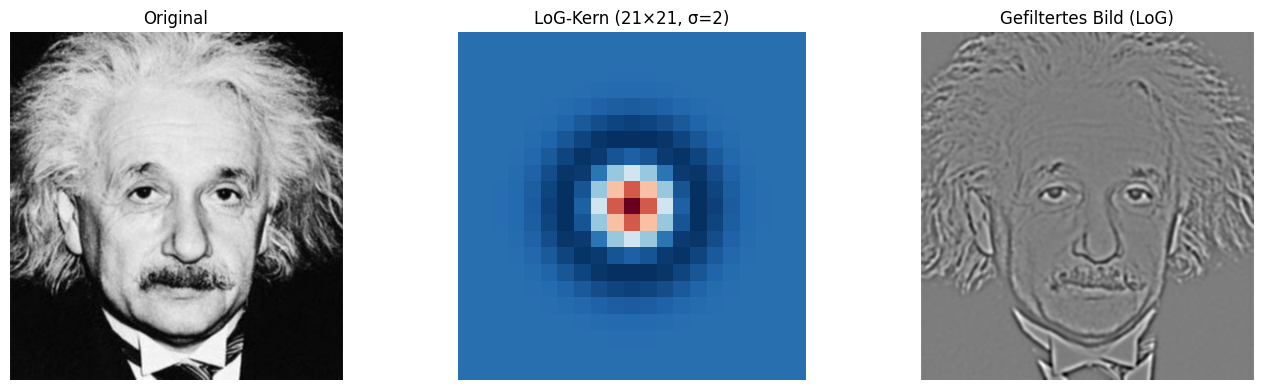

In [78]:
# Kombinierter LoG-Kern via Impulsantwort:
# Base kernel (21x21) mit einer 1 in der Mitte, sonst 0
kernel_size = 21
base_kernel = np.zeros((kernel_size, kernel_size))
base_kernel[kernel_size // 2, kernel_size // 2] = 1.0

# Gauß-Filter (sigma=2)
gauss_kernel = gaussian(base_kernel, sigma=2)

# Laplace-Filter auf Gauß-Kernel → kombinierter LoG-Kernel (21x21)
log_kernel = laplace(gauss_kernel)

# Faltung LoG-Kernel mit dem Originalbild
img_log = convolve(img_original.astype(float), log_kernel)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(log_kernel, cmap='RdBu_r')
axes[1].set_title('LoG-Kern (21×21, σ=2)')
axes[1].axis('off')

axes[2].imshow(img_log, cmap='gray')
axes[2].set_title('Gefiltertes Bild (LoG)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 2.3

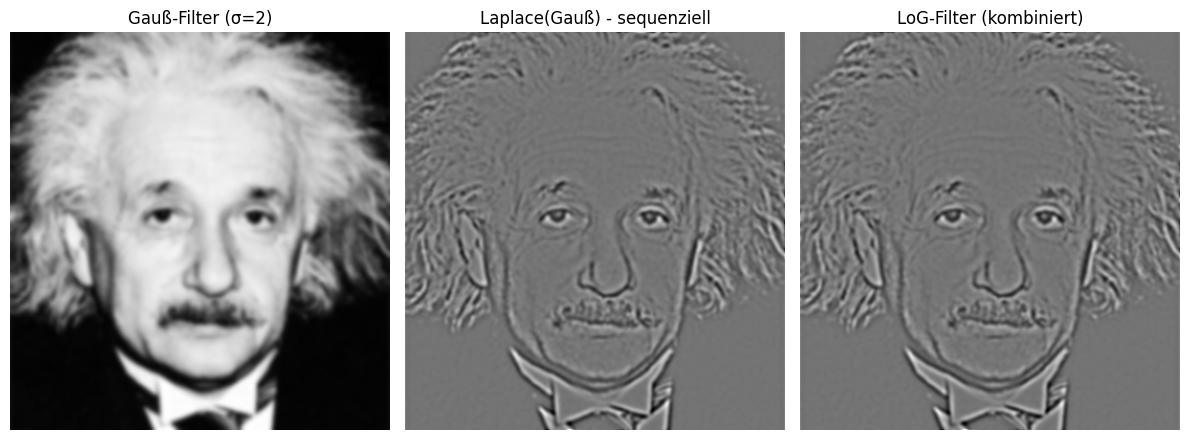

Diffrerenz der Bilder: 0.000000
=> Die Bilder sind gleich.
ZEITVERGLEICH (100 Iterationen):
Sequenziell (Gauß + Laplace):  227.8848 ms
Kombiniert (LoG):              195.5390 ms
Speedup: 1.17x


In [80]:
# Skalierung für Visualisierung
img_scaled = (img_original - img_original.min()) / (img_original.max() - img_original.min())
img_scaled = img_scaled.astype(float)

laplace_kernel = laplace(base_kernel)

# Methode 1: Gauß und Laplace sequenziell (mit direkten Funktionen)
start = time.time()
for i in range(100):
    img_gaussian = gaussian(img_scaled, sigma=2)
    img_laplace_seq = laplace(img_gaussian)
time_sequential = time.time() - start

# Methode 2: Kombinierter LoG-Filter
start = time.time()
for i in range(100):
    img_log_result = laplace(gaussian(img_scaled, sigma=2))
time_combined = time.time() - start

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(img_gaussian, cmap='gray')
axes[0].set_title('Gauß-Filter (σ=2)')
axes[0].axis('off')

axes[1].imshow(img_laplace_seq, cmap='gray')
axes[1].set_title('Laplace(Gauß) - sequenziell')
axes[1].axis('off')

axes[2].imshow(img_log_result, cmap='gray')
axes[2].set_title('LoG-Filter (kombiniert)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Diffrerenz der Bilder: {np.max(np.abs(img_laplace_seq - img_log_result)):.6f}")
print("=> Die Bilder sind gleich.")

print("=" * 70)
print("ZEITVERGLEICH (100 Iterationen):")
print("=" * 70)
print(f"Sequenziell (Gauß + Laplace):  {time_sequential*1000:.4f} ms")
print(f"Kombiniert (LoG):              {time_combined*1000:.4f} ms")
speedup = time_sequential/time_combined
print(f"Speedup: {speedup:.2f}x")

